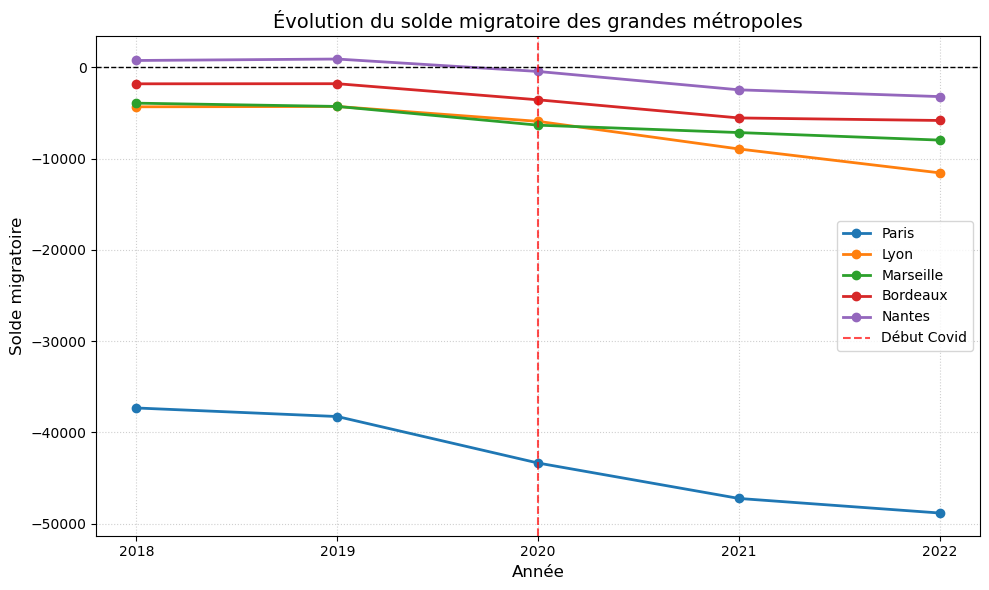

graphique généré...


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs', exist_ok=True)
df = pd.read_csv('../outputs/flux_migratoire_triee.csv', sep=';', dtype={'code_orig': str, 'code_dest': str})

#les grandes villes qu'on analyse
def categoriser(code):
    code = str(code)
    if code.startswith('751'): return 'Paris'
    if code.startswith('6938'): return 'Lyon'
    if code.startswith('132'): return 'Marseille'
    if code == '31555': return 'Toulouse'
    if code == '33063': return 'Bordeaux'
    if code == '44109': return 'Nantes'
    return 'Reste de la France'

df['ville_orig'] = df['code_orig'].apply(categoriser)
df['ville_dest'] = df['code_dest'].apply(categoriser)

#calcul du solde migratoire annuel
entrees = df.groupby(['annee', 'ville_dest'])['flux'].sum().reset_index()
entrees.columns = ['annee', 'ville', 'arrivées']
sorties = df.groupby(['annee', 'ville_orig'])['flux'].sum().reset_index()
sorties.columns = ['annee', 'ville', 'départs']

#arrivées - départs
bilan = pd.merge(entrees, sorties, on=['annee', 'ville'])
bilan['solde'] = bilan['arrivées'] - bilan['départs']

plt.figure(figsize=(10, 6))
villes_test = ['Paris', 'Lyon', 'Marseille', 'Bordeaux', 'Nantes']

for v in villes_test:
    data_v = bilan[bilan['ville'] == v]
    plt.plot(data_v['annee'].astype(str), data_v['solde'], marker='o', linewidth=2, label=v)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(x='2020', color='red', linestyle='--', alpha=0.7, label='Début Covid')
plt.title("Évolution du solde migratoire des grandes métropoles", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Solde migratoire", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../outputs/graphique_solde_migra.png', dpi=300)
plt.show()

print("graphique généré...")